# Transportia — Modelado de la solución (Entregable 3)

**Ciencia de Datos Aplicada — ITBA**

**Pipeline de predicción de travel time y headway para colectivos del AMBA**

Este notebook presenta los resultados del pipeline modular construido para:
- Predecir el tiempo de viaje entre paradas consecutivas (travel time)
- Predecir el intervalo entre colectivos en una parada (headway)
- Analizar la eficiencia de las rutas respecto al plan GTFS
- Simular rutas alternativas evaluando impacto en travel time y headway

## Glosario

| Término | Definición |
|---|---|
| **Travel time** | Tiempo en segundos que tarda un colectivo en ir de una parada a la siguiente. No es el tiempo total del recorrido, sino el de un segmento individual. La mediana es ~62s para distancias de ~364m. |
| **Headway** | Intervalo en segundos entre la llegada de un colectivo y el siguiente a la misma parada, en la misma ruta y dirección. Representa la frecuencia del servicio. |
| **Segmento** | El tramo entre parada A y parada B consecutivas de un recorrido. |
| **GTFS** | General Transit Feed Specification — formato estándar de datos de transporte público. Contiene recorridos planificados, horarios y frecuencias. |

In [72]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

OUTPUTS = Path("../outputs")

def load_parquet(name):
    p = OUTPUTS / name
    if p.exists():
        return pd.read_parquet(p)
    print(f"⚠ {name} no encontrado. Ejecutar los scripts primero.")
    return pd.DataFrame()

def add_grid(ax):
    ax.grid(True, alpha=0.3, color="gray", linestyle="--")

print("Listo para cargar outputs.")

Listo para cargar outputs.


## Carga y preparación

Cargamos los outputs generados por los scripts 01-03 del pipeline.

**Filtros aplicados en el feature engineering:**
- Solo rutas con centroid en CABA + primer cordón (lat: -34.75 a -34.50, lon: -58.65 a -58.30)
- Top 200 rutas por cantidad de observaciones
- Travel time: solo segmentos entre 5s y 600s (10 min)
- Headway: solo valores entre 30s y 900s (15 min)

In [73]:
stop_events = load_parquet("stop_events.parquet")
segments_raw = load_parquet("segments_raw.parquet")
headway_raw = load_parquet("headway_raw.parquet")
segments_feat = load_parquet("segments_features.parquet")
headway_feat = load_parquet("headway_features.parquet")

In [74]:
print("=== Resumen de datos ===")
for name, df in [("Stop Events", stop_events), ("Segments Raw", segments_raw),
                  ("Headway Raw", headway_raw), ("Segments Features", segments_feat),
                  ("Headway Features", headway_feat)]:
    if not df.empty:
        print(f"{name}: {len(df):,} filas x {df.shape[1]} columnas")
    else:
        print(f"{name}: no disponible")

=== Resumen de datos ===
Stop Events: 27,291,258 filas x 15 columnas
Segments Raw: 4,626,522 filas x 18 columnas
Headway Raw: 4,159,128 filas x 7 columnas
Segments Features: 1,879,618 filas x 26 columnas
Headway Features: 930,845 filas x 13 columnas


In [75]:
if not segments_feat.empty:
    print("=== Segmentos — Estadísticas ===")
    print(segments_feat[["distance_m", "travel_time_observed"]].describe())
else:
    print("No hay datos de segmentos features.")

=== Segmentos — Estadísticas ===
         distance_m  travel_time_observed
count  1.365555e+06          1.879618e+06
mean   5.005725e+02          9.246169e+01
std    9.844647e+02          6.051777e+01
min    0.000000e+00          8.000000e+00
25%    2.554851e+02          6.000000e+01
50%    3.608556e+02          6.200000e+01
75%    5.222437e+02          1.200000e+02
max    7.323992e+04          6.000000e+02


In [76]:
if not headway_feat.empty:
    print("=== Headway — Estadísticas ===")
    print(headway_feat[["headway_observed"]].describe())
else:
    print("No hay datos de headway features.")

=== Headway — Estadísticas ===
       headway_observed
count     930845.000000
mean         410.796358
std          253.179707
min           30.000000
25%          180.000000
50%          388.000000
75%          604.000000
max          900.000000


## Qué predice cada modelo

### Modelo A: Travel Time
Dado un segmento entre dos paradas, predice **cuántos segundos tarda el colectivo** en recorrerlo.

**Variables de entrada:**
- `distance_m`: distancia haversine entre paradas (metros)
- `zone_lat/lon`: coordenadas del punto medio (captura congestión por zona)
- `hour_bin`: franja horaria (0=madrugada, 1=pico mañana, 2=mediodía, 3=pico tarde, 4=noche)
- `day_type`: día de semana vs fin de semana
- `route_enc`: frecuencia de la ruta (proxy de importancia de la línea)
- `n_semaphores`: semáforos cerca del segmento
- `pct_semaphores_operational`: fracción de semáforos funcionando

### Modelo B: Headway
Dada una parada y un momento del día, predice **cuántos segundos van a pasar** entre colectivos consecutivos.

**Variables de entrada:**
- `stop_lat/lon`: coordenadas de la parada
- `hour_bin_enc` / `day_type_enc`: momento temporal
- `n_vehicles_active`: colectivos activos en esa ruta+hora
- `headway_programado`: frecuencia planificada según GTFS
- `route_enc`: frecuencia de la ruta

## Entrenamiento

Se entrenaron dos modelos con **GridSearchCV** (búsqueda exhaustiva de hiperparámetros con validación cruzada 3-fold):
- **Modelo A (Travel Time):** XGBoost vs Random Forest
- **Modelo B (Headway):** Random Forest vs Gradient Boosting

**Metodología:**
- Split 80/20 estratificado por `route + hour_bin`
- Seleccionado por menor RMSE
- Se comparan contra baselines (predicción de la media, distancia bucket, GTFS programado)

In [77]:
metrics_tt_path = OUTPUTS / "metrics_travel_time.json"
metrics_hw_path = OUTPUTS / "metrics_headway.json"

if metrics_tt_path.exists():
    with open(metrics_tt_path) as f:
        metrics_tt = json.load(f)
    print("=== Travel Time Model — Métricas ===")
    df_metrics_tt = pd.DataFrame(metrics_tt["results"])
    print(df_metrics_tt.to_string(index=False))
    print(f"\nMejor modelo: {metrics_tt['best_model']}")
else:
    print("⚠ metrics_travel_time.json no encontrado.")

=== Travel Time Model — Métricas ===
                 model       MAE      RMSE        R2
               XGBoost 37.234544 51.582804  0.380460
          RandomForest 34.617743 49.289332  0.434327
       Baseline (mean) 47.741000 65.535235 -0.000021
Baseline (dist bucket) 48.679246 66.606522 -0.032982

Mejor modelo: RandomForest


In [78]:
if metrics_hw_path.exists():
    with open(metrics_hw_path) as f:
        metrics_hw = json.load(f)
    print("=== Headway Model — Métricas ===")
    df_metrics_hw = pd.DataFrame(metrics_hw["results"])
    print(df_metrics_hw.to_string(index=False))
    print(f"\nMejor modelo: {metrics_hw['best_model']}")
else:
    print("⚠ metrics_headway.json no encontrado.")

=== Headway Model — Métricas ===
           model        MAE        RMSE         R2
    RandomForest 199.440009  235.953234   0.110965
GradientBoosting 194.758367  232.681826   0.135446
 GTFS programado 953.218766 1069.333743 -17.259703

Mejor modelo: GradientBoosting


### Métricas explicadas

| Métrica | Qué mide | Interpretación |
|---|---|---|
| **MAE** (Mean Absolute Error) | Error promedio absoluto en segundos | "En promedio, el modelo se equivoca por X segundos". Fácil de interpretar. |
| **RMSE** (Root Mean Squared Error) | Raíz del error cuadrático medio | Penaliza más los errores grandes. Si hay outliers de predicción, el RMSE será mucho mayor que el MAE. |
| **R²** (Coeficiente de determinación) | Fracción de la varianza explicada | 1.0 = predicción perfecta. 0.0 = equivalente a predecir la media. <0 = peor que predecir la media. |

**Baseline:** Predecir siempre la media del train set. Si el modelo no le gana a esto, no sirve.

## Métricas y visualización

Feature Importance — Travel Time Model


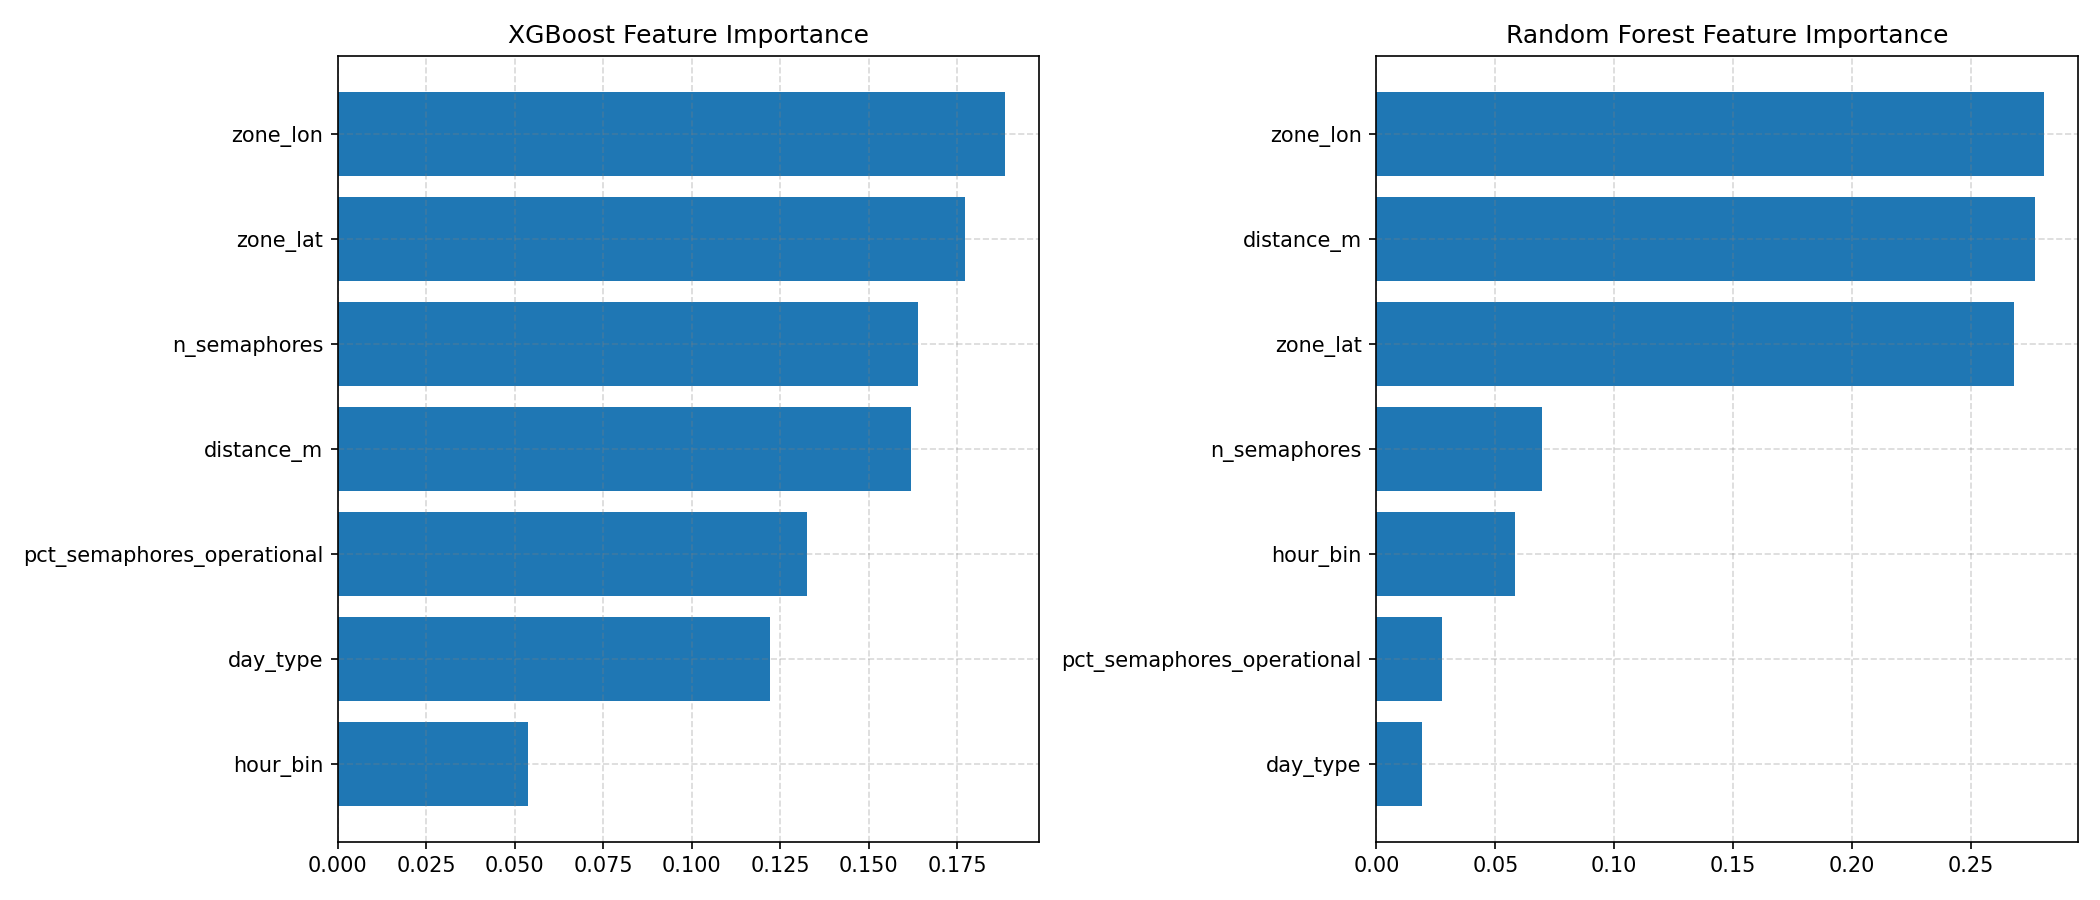

In [79]:
fi_tt_path = OUTPUTS / "feature_importance_travel_time.png"
fi_hw_path = OUTPUTS / "feature_importance_headway.png"

if fi_tt_path.exists():
    from IPython.display import Image, display
    print("Feature Importance — Travel Time Model")
    display(Image(filename=str(fi_tt_path)))
else:
    print("⚠ feature_importance_travel_time.png no encontrado.")

Feature Importance — Headway Model


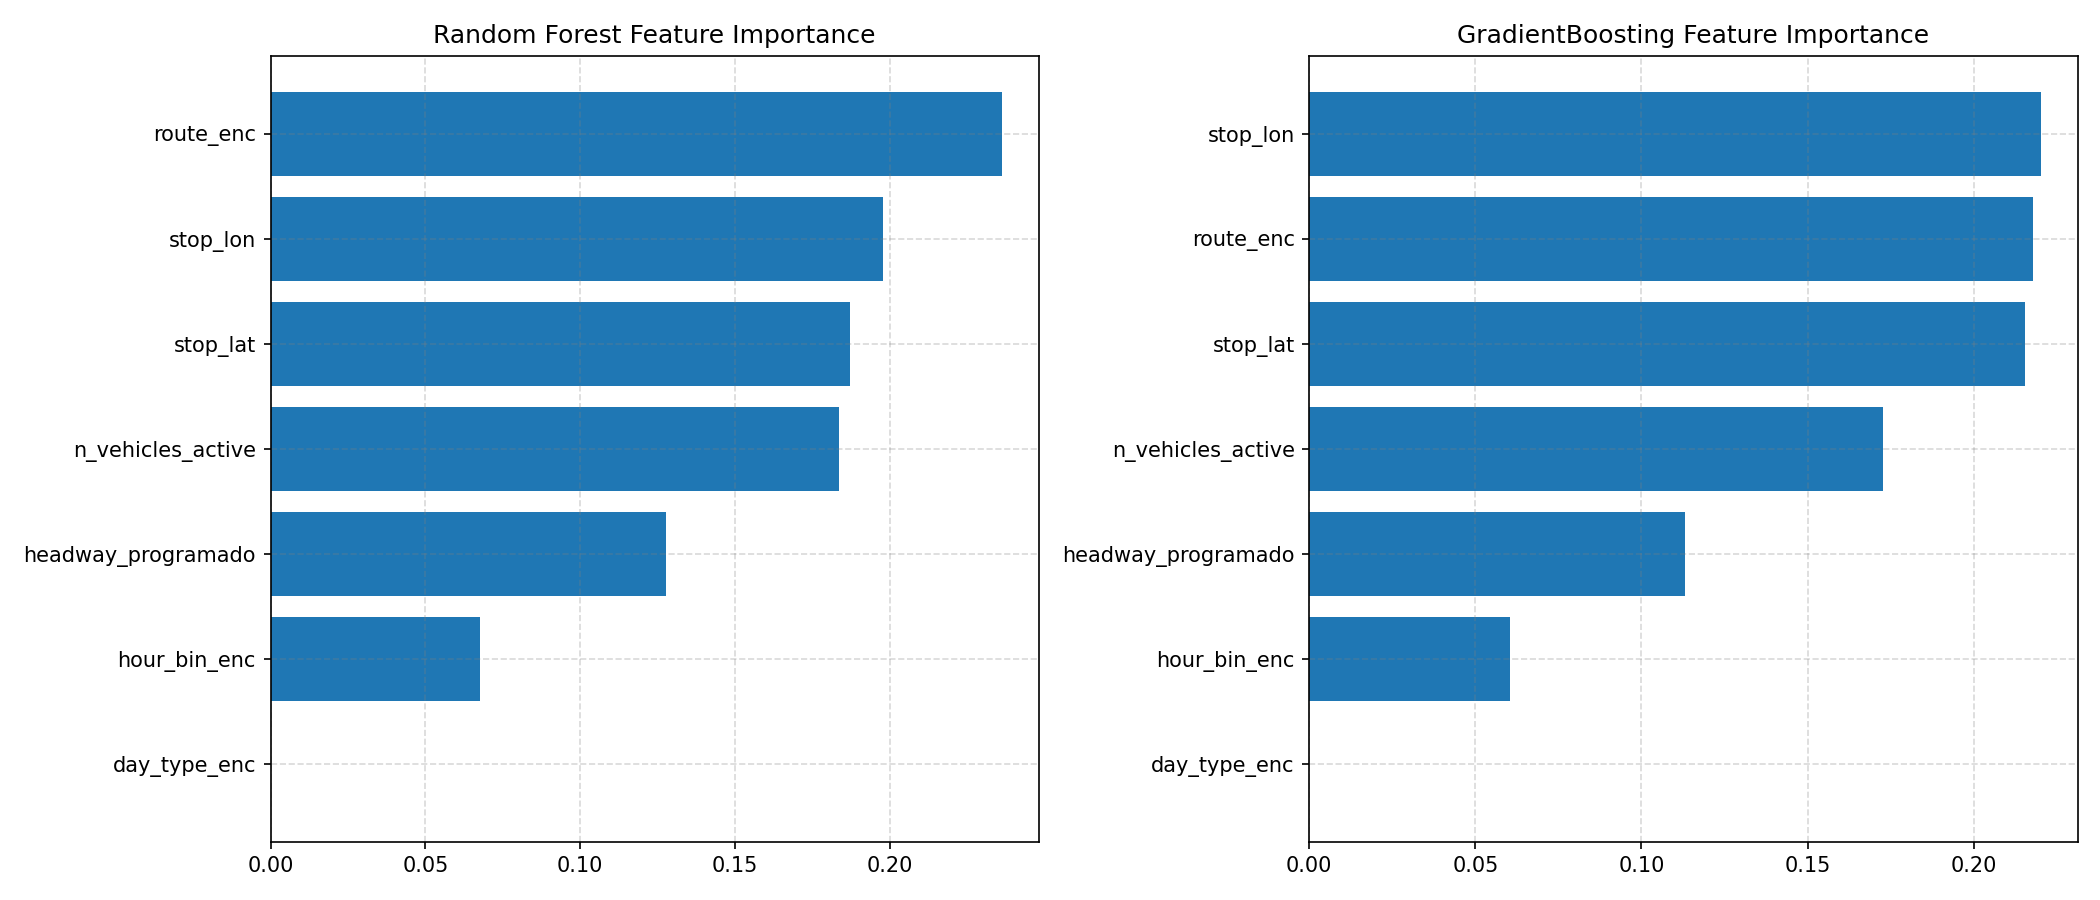

In [80]:
if fi_hw_path.exists():
    from IPython.display import Image, display
    print("Feature Importance — Headway Model")
    display(Image(filename=str(fi_hw_path)))
else:
    print("⚠ feature_importance_headway.png no encontrado.")

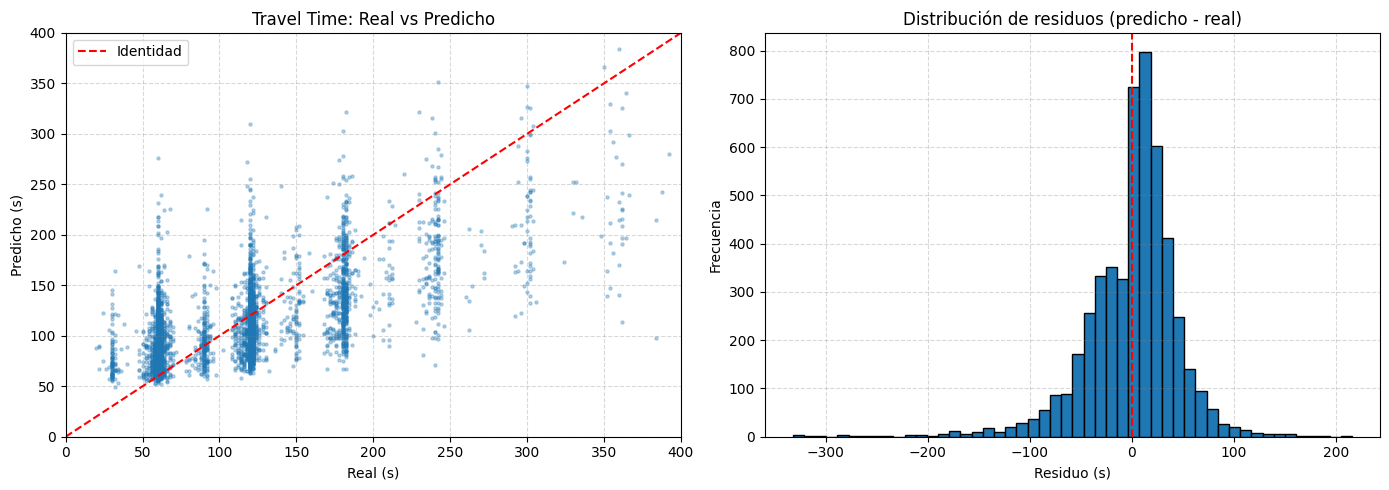

In [81]:
if not segments_feat.empty and metrics_tt_path.exists():
    model_tt = joblib.load(OUTPUTS / "model_travel_time.joblib")
    features = model_tt["features"]
    feat_df = segments_feat.dropna(subset=features + ["travel_time_observed"]).copy()

    feat_df = feat_df[feat_df["travel_time_observed"] <= 600]

    hour_map = {"early_morning": 0, "morning_peak": 1, "midday": 2, "evening_peak": 3, "night": 4}
    day_map = {"weekday": 0, "weekend": 1}
    if "hour_bin" in feat_df.columns:
        feat_df["hour_bin"] = feat_df["hour_bin"].map(hour_map).fillna(2)
    if "day_type" in feat_df.columns:
        feat_df["day_type"] = feat_df["day_type"].map(day_map).fillna(0)
    if "route_short_name" in feat_df.columns:
        freq = feat_df["route_short_name"].value_counts()
        feat_df["route_enc"] = feat_df["route_short_name"].map(freq).fillna(0).astype(int)

    available_features = [c for c in features if c in feat_df.columns]
    sample = feat_df.sample(min(5000, len(feat_df)), random_state=42)
    X_sample = sample[available_features].values
    y_sample = sample["travel_time_observed"].values
    preds = model_tt["model"].predict(X_sample)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].scatter(y_sample, preds, alpha=0.3, s=5)
    max_val = 400
    axes[0].plot([0, max_val], [0, max_val], "r--", label="Identidad")
    axes[0].set_xlabel("Real (s)")
    axes[0].set_ylabel("Predicho (s)")
    axes[0].set_title("Travel Time: Real vs Predicho")
    axes[0].set_xlim(0, max_val)
    axes[0].set_ylim(0, max_val)
    axes[0].legend()
    add_grid(axes[0])

    residuals = preds - y_sample
    axes[1].hist(residuals, bins=50, edgecolor="black")
    axes[1].axvline(0, color="r", linestyle="--")
    axes[1].set_xlabel("Residuo (s)")
    axes[1].set_ylabel("Frecuencia")
    axes[1].set_title("Distribución de residuos (predicho - real)")
    add_grid(axes[1])

    plt.tight_layout()
    plt.show()
else:
    print("No hay datos suficientes para generar scatter plot.")

### Lectura de los gráficos de diagnóstico

**Scatter plot (izquierda):** Cada punto es un segmento. El eje X es el tiempo real, el Y el predicho. Si el modelo fuera perfecto, todos los puntos caerían sobre la línea roja (identidad). Puntos por encima = sobreestima, por debajo = subestima.

**Distribución de residuos (derecha):** Histograma de `predicho - real`. Un modelo sin sesgo tiene la distribución centrada en 0. Si está corrida a la derecha, el modelo tiende a sobreestimar. Una distribución angosta = errores pequeños.

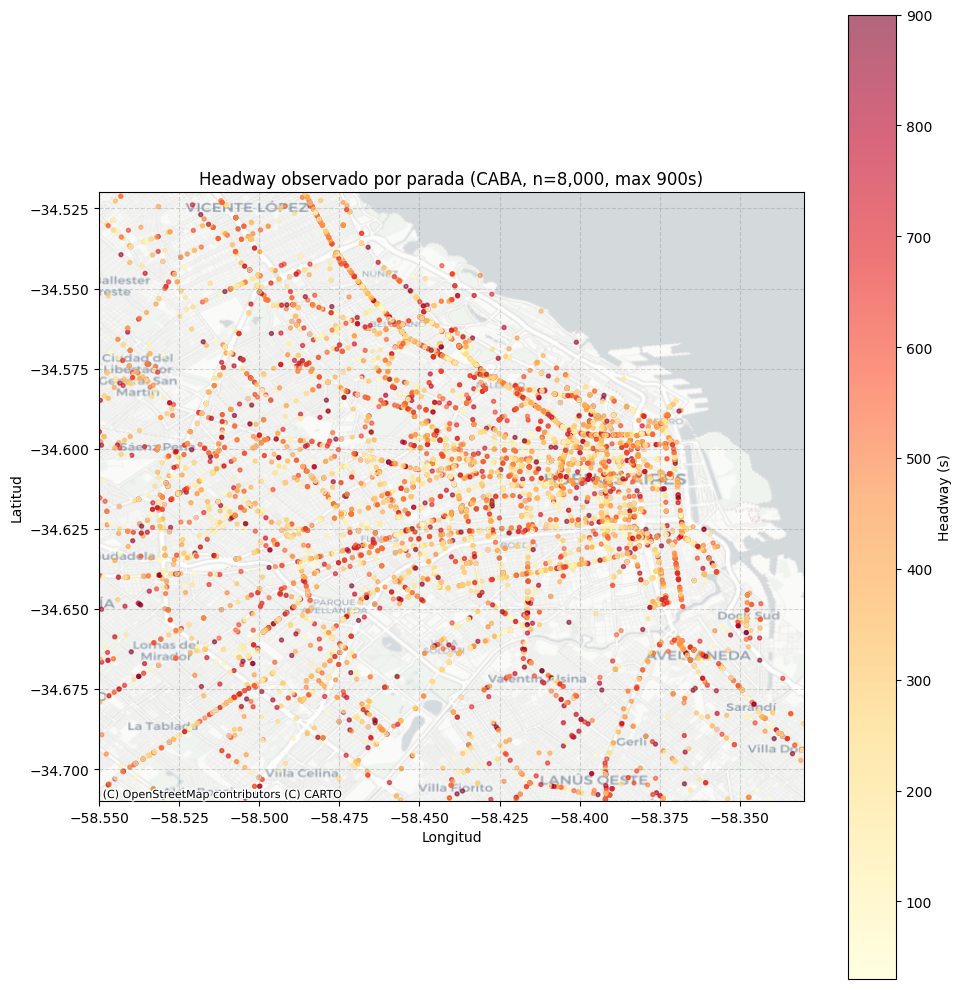

In [82]:
if not headway_feat.empty:
    hw = headway_feat.dropna(subset=["headway_observed"])
    hw = hw[hw["headway_observed"] <= 900]
    if "stop_lat" in hw.columns and "stop_lon" in hw.columns:
        CABA_LAT = (-34.71, -34.52)
        CABA_LON = (-58.55, -58.33)
        hw_caba = hw[hw["stop_lat"].between(*CABA_LAT) & hw["stop_lon"].between(*CABA_LON)]
        fig, ax = plt.subplots(figsize=(10, 10))
        add_grid(ax)
        sample_hw = hw_caba.sample(min(8000, len(hw_caba)), random_state=42)
        sc = ax.scatter(
            sample_hw["stop_lon"], sample_hw["stop_lat"],
            c=sample_hw["headway_observed"], cmap="YlOrRd",
            s=8, alpha=0.6, vmin=30, vmax=900
        )
        plt.colorbar(sc, label="Headway (s)")
        ax.set_xlim(*CABA_LON)
        ax.set_ylim(*CABA_LAT)
        ax.set_xlabel("Longitud")
        ax.set_ylabel("Latitud")
        ax.set_title(f"Headway observado por parada (CABA, n={len(sample_hw):,}, max 900s)")
        ax.set_aspect("equal")
        try:
            import contextily as cx
            cx.add_basemap(ax, crs="EPSG:4326", source=cx.providers.CartoDB.Positron)
        except Exception:
            pass
        plt.tight_layout()
        plt.show()
    else:
        print("No hay coordenadas de parada en headway features.")
else:
    print("No hay datos de headway features.")

## Análisis de resultados

In [83]:
route_scores = load_parquet("route_scores.parquet")
if not route_scores.empty:
    print("=== Eficiencia de rutas ===")
    print(f"Rutas analizadas: {len(route_scores)}")
    print(f"\nTop 10 peores rutas:")
    cols = ["route_short_name", "spatial_deviation_m", "temporal_deviation_pct", "efficiency_score"]
    print(route_scores.head(10)[[c for c in cols if c in route_scores.columns]].to_string(index=False))
    print(f"\nTop 10 mejores rutas:")
    print(route_scores.tail(10).iloc[::-1][[c for c in cols if c in route_scores.columns]].to_string(index=False))
else:
    print("⚠ route_scores.parquet no encontrado.")

=== Eficiencia de rutas ===
Rutas analizadas: 400

Top 10 peores rutas:
route_short_name  spatial_deviation_m  temporal_deviation_pct  efficiency_score
            318B        131057.526442              333.273092      68861.494144
            202D        116660.181545              304.799197      61378.082740
            101B        112608.808151              333.564257      59640.046646
         506R80A         92513.088177              250.933735      48765.881438
           520CB         88691.935468              251.777108      46863.738818
          214B64         83185.959659              151.104418      43104.024006
         506R80A         78276.322353              333.554217      42473.703345
           247R7         75220.492670              407.540161      41685.647941
          214B64         77082.962552              144.447791      39985.959188
           520CB         68615.413892              346.797189      37775.678833

Top 10 mejores rutas:
route_short_name  spatial

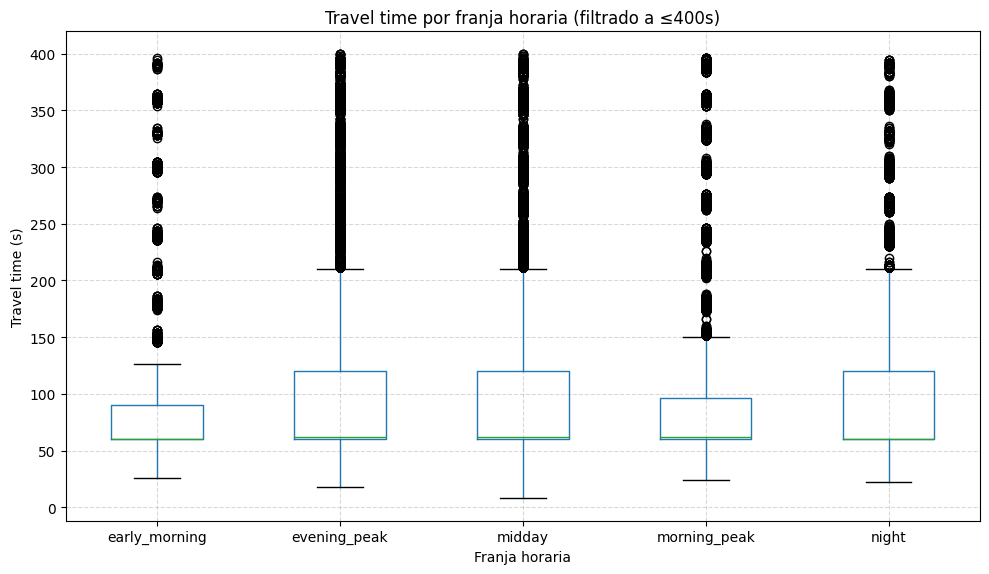

In [84]:
if not segments_feat.empty and "hour_bin" in segments_feat.columns:
    fig, ax = plt.subplots(figsize=(10, 6))
    add_grid(ax)
    order = ["early_morning", "morning_peak", "midday", "evening_peak", "night"]
    existing = [h for h in order if h in segments_feat["hour_bin"].unique()]
    if existing:
        plot_data = segments_feat[segments_feat["hour_bin"].isin(existing)]
        plot_data = plot_data[plot_data["travel_time_observed"] <= 400]
        plot_data.boxplot(
            column="travel_time_observed", by="hour_bin", ax=ax
        )
        ax.set_title("Travel time por franja horaria (filtrado a ≤400s)")
        ax.set_xlabel("Franja horaria")
        ax.set_ylabel("Travel time (s)")
        plt.suptitle("")
        plt.tight_layout()
        plt.show()
    else:
        print("No hay datos de hour_bin para visualizar.")
else:
    print("No hay datos de segmentos features.")

## Simulador de rutas — Optimización con grafo de paradas

### Cómo funciona

1. **Selecciona la peor ruta** del análisis de eficiencia (mayor `efficiency_score`)

2. **Identifica zonas congestionadas**: segmentos donde el travel time observado es significativamente mayor al esperado para la distancia (p85 del tiempo, controlado por velocidad media de la ruta)

3. **Busca caminos alternativos** en un grafo de paradas que incluye TODAS las líneas de colectivos de la zona. Las aristas del grafo tienen como peso el travel time (mediana observada si hay datos, estimado por OSRM/haversine si no)

4. **Valida que los gaps entre paradas no superen 500m**: si el camino alternativo tiene un tramo muy largo, busca una parada intermedia de otra línea para mantener cobertura

5. **Calcula el ahorro total**: diferencia entre el travel time original de las zonas congestionadas y el del camino alternativo

### Limitaciones
- Las aristas sin datos observados se estiman con velocidad constante (haversine/4.6 m/s) o con OSRM si está disponible
- No modela demanda de pasajeros ni capacidad del colectivo
- Asume que se puede usar cualquier parada de otras líneas sin cambios de infraestructura
- No considera que al eliminar paradas, algunos pasajeros deberán caminar más

### Routing con OSRM

Si el servidor OSRM local está corriendo (`docker compose -f docker-compose.osrm.yml up -d`), el simulador usa rutas reales de calles para estimar distancias y tiempos. Si no, usa distancias haversine (línea recta) como fallback.

In [85]:
import sys, networkx as nx
from scipy.spatial import cKDTree
sys.path.insert(0, str(Path('../scripts').resolve()))
from utils import haversine_m
from osrm_routing import is_osrm_available, get_route

MAX_GAP_M = 500
MEDIAN_SPEED = 4.6

sf = load_parquet('segments_features.parquet')
if sf.empty:
    print('Run scripts 01-03 first.')
else:
    route_scores_loaded = load_parquet('route_scores.parquet')
    if not route_scores_loaded.empty:
        worst_route = route_scores_loaded.iloc[0]['route_short_name']
    else:
        worst_route = sf['route_short_name'].value_counts().index[0]

    r_data = sf[(sf['route_short_name'] == worst_route) & sf['stop_A_lat'].notna()]
    if r_data.empty:
        worst_route = sf['route_short_name'].value_counts().index[0]
        r_data = sf[(sf['route_short_name'] == worst_route) & sf['stop_A_lat'].notna()]

    use_osrm = is_osrm_available()
    print(f'OSRM: {"Disponible (calles reales)" if use_osrm else "No disponible (haversine)"}')

    best_trip = r_data.groupby('trip_id').size().sort_values(ascending=False).index[0]
    trip_data = r_data[r_data['trip_id'] == best_trip]

    stops_seq = trip_data.groupby('arrival_seq').agg(
        stop_id=('stop_id_A', 'first'), lat=('stop_A_lat', 'median'), lon=('stop_A_lon', 'median'),
    ).sort_index().reset_index(drop=True)

    seg_stats = trip_data[trip_data['next_seq'] == trip_data['arrival_seq'] + 1].groupby(
        'arrival_seq'
    ).agg(
        med_tt=('travel_time_observed', 'median'),
        med_dist=('distance_m', 'median'),
    ).sort_index().reset_index(drop=True)

    total_tt = seg_stats['med_tt'].sum()
    print(f'Linea {worst_route} — Trip {best_trip}')
    print(f'  {len(stops_seq)} paradas, {seg_stats["med_dist"].sum():.0f}m totales')
    print(f'  Tiempo total observado: {total_tt:.0f}s ({total_tt/60:.1f} min)')

    all_a = sf[['stop_id_A','stop_A_lat','stop_A_lon']].dropna().drop_duplicates('stop_id_A')
    all_a.columns = ['stop_id','lat','lon']
    all_b = sf[['stop_id_B','stop_B_lat','stop_B_lon']].dropna().drop_duplicates('stop_id_B')
    all_b.columns = ['stop_id','lat','lon']
    all_stops = pd.concat([all_a, all_b]).drop_duplicates('stop_id')

    bbox_lat = (stops_seq['lat'].min()-0.015, stops_seq['lat'].max()+0.015)
    bbox_lon = (stops_seq['lon'].min()-0.015, stops_seq['lon'].max()+0.015)
    nearby = all_stops[all_stops['lat'].between(*bbox_lat) & all_stops['lon'].between(*bbox_lon)]
    stop_routes = sf.dropna(subset=['stop_A_lat']).groupby('stop_id_A')[
        'route_short_name'].apply(lambda x: list(x.unique())[:5]).to_dict()

    graph_edges = sf.dropna(subset=['stop_A_lat']).groupby(['stop_id_A','stop_id_B']).agg(
        med_tt=('travel_time_observed','median'), n=('travel_time_observed','count'),
    ).reset_index()
    graph_edges = graph_edges[graph_edges['n'] >= 3]
    zone_ids = set(nearby['stop_id'])
    ze = graph_edges[graph_edges['stop_id_A'].isin(zone_ids) & graph_edges['stop_id_B'].isin(zone_ids)]

    bus_graph = nx.DiGraph()
    for _, r in ze.iterrows():
        bus_graph.add_edge(r['stop_id_A'], r['stop_id_B'], weight=r['med_tt'])

    route_stop_ids = set(stops_seq['stop_id'])
    coords = np.radians(nearby[['lat','lon']].values)
    tree = cKDTree(coords)
    radius_rad = (MAX_GAP_M * 2) / 6_371_000
    pairs = tree.query_pairs(radius_rad)
    for i, j in pairs:
        s, t = nearby.iloc[i], nearby.iloc[j]
        if s['stop_id'] in route_stop_ids and t['stop_id'] in route_stop_ids:
            continue
        if not bus_graph.has_edge(s['stop_id'], t['stop_id']):
            d = haversine_m(s['lat'], s['lon'], t['lat'], t['lon'])
            est_tt = d / MEDIAN_SPEED
            if use_osrm:
                route = get_route(s['lon'], s['lat'], t['lon'], t['lat'])
                if route:
                    est_tt = route['duration_s']
            if use_osrm:
                route = get_route(s['lon'], s['lat'], t['lon'], t['lat'])
                if route:
                    est_tt = route['duration_s']
                    bus_graph.add_edge(s['stop_id'], t['stop_id'], weight=est_tt, geometry=route['geometry'])
                    bus_graph.add_edge(t['stop_id'], s['stop_id'], weight=est_tt, geometry=route['geometry'])
                    continue
            bus_graph.add_edge(s['stop_id'], t['stop_id'], weight=est_tt)
            bus_graph.add_edge(t['stop_id'], s['stop_id'], weight=est_tt)

    print(f'  Grafo: {bus_graph.number_of_nodes()} nodos, {bus_graph.number_of_edges()} aristas')

OSRM: Disponible (calles reales)
Linea 318B — Trip 78691-1
  74 paradas, 7334m totales
  Tiempo total observado: 2724s (45.4 min)
  Grafo: 1556 nodos, 125810 aristas


In [86]:
p90 = seg_stats['med_tt'].quantile(0.85)
mean_speed = seg_stats['med_dist'].sum() / seg_stats['med_tt'].sum()

zones = []
i = 0
while i < len(seg_stats):
    if seg_stats.iloc[i]['med_tt'] > p90:
        start = i
        while i < len(seg_stats) and seg_stats.iloc[i]['med_tt'] > p90 * 0.6:
            i += 1
        end = min(i, len(seg_stats))
        if end - start >= 1:
            zt = seg_stats.iloc[start:end]['med_tt'].sum()
            zd = seg_stats.iloc[start:end]['med_dist'].sum()
            expected = zd / mean_speed
            if zt > expected * 1.3 and zt > 120:
                zones.append({'start': start, 'end': end, 'tt': zt, 'dist': zd})
    else:
        i += 1

all_stops_map = nearby.set_index('stop_id')[['lat','lon']].to_dict('index')
proposals = []

for z in zones:
    a = stops_seq.iloc[z['start']]
    b = stops_seq.iloc[z['end']]
    try:
        path = nx.shortest_path(bus_graph, a['stop_id'], b['stop_id'], weight='weight')
        path_tt = sum(bus_graph[path[i]][path[i+1]]['weight'] for i in range(len(path)-1))
    except (nx.NetworkXNoPath, KeyError):
        path = [a['stop_id'], b['stop_id']]
        path_tt = z['tt']

    removed = [stops_seq.iloc[idx]['stop_id'] for idx in range(z['start']+1, z['end'])]
    new_stops = []
    for sid in path[1:-1]:
        info = all_stops_map.get(sid)
        if info:
            new_stops.append({'stop_id': sid, 'lat': info['lat'], 'lon': info['lon'],
                              'lines': stop_routes.get(sid, [])[:5],
                              'is_new': sid not in route_stop_ids})

    all_pts = [(a['lat'], a['lon'])]
    for ns in new_stops:
        all_pts.append((ns['lat'], ns['lon']))
    all_pts.append((b['lat'], b['lon']))

    extra = []
    for idx in range(len(all_pts)-1):
        gap = haversine_m(all_pts[idx][0], all_pts[idx][1], all_pts[idx+1][0], all_pts[idx+1][1])
        if gap > MAX_GAP_M:
            mid = ((all_pts[idx][0]+all_pts[idx+1][0])/2, (all_pts[idx][1]+all_pts[idx+1][1])/2)
            close = nearby[(abs(nearby['lat']-mid[0])<0.003) & (abs(nearby['lon']-mid[1])<0.003)
                            & (~nearby['stop_id'].isin(route_stop_ids))]
            if not close.empty:
                c = close.iloc[0]
                extra.append({'stop_id': c['stop_id'], 'lat': c['lat'], 'lon': c['lon'],
                              'lines': stop_routes.get(c['stop_id'], [])[:5], 'gap': gap})

    max_gap = max(haversine_m(all_pts[i][0], all_pts[i][1], all_pts[i+1][0], all_pts[i+1][1])
                  for i in range(len(all_pts)-1))

    path_geometry = []
    for k in range(len(path) - 1):
        edge_data = bus_graph[path[k]][path[k+1]]
        geom = edge_data.get('geometry')
        if geom:
            path_geometry.extend(geom)
        else:
            s_info = all_stops_map.get(path[k])
            t_info = all_stops_map.get(path[k+1])
            if s_info and t_info:
                path_geometry.append([s_info['lon'], s_info['lat']])
                path_geometry.append([t_info['lon'], t_info['lat']])

    proposals.append({
        'zone': f"seq {z['start']}->{z['end']}", 'stop_A': a['stop_id'], 'stop_B': b['stop_id'],
        'lat_A': a['lat'], 'lon_A': a['lon'], 'lat_B': b['lat'], 'lon_B': b['lon'],
        'original_tt': z['tt'], 'original_dist': z['dist'],
        'removed': removed, 'new_stops': new_stops, 'extra': extra,
        'alt_tt': path_tt, 'savings': max(0, z['tt'] - path_tt), 'max_gap': max_gap,
        'path_geometry': path_geometry,
    })

    removed_str = ', '.join(removed)
    print(f"Zona {proposals[-1]['zone']}: {a['stop_id']} -> {b['stop_id']}")
    print(f"  Problema: {z['tt']:.0f}s en {z['dist']:.0f}m")
    print(f"  Eliminar: {removed_str}")
    for ns in new_stops:
        tag = '(NUEVA)' if ns['is_new'] else ''
        lines = ', '.join(ns['lines'][:3])
        print(f"  Agregar: {ns['stop_id']}{tag} [{lines}]")
    for es in extra:
        lines = ', '.join(es['lines'][:3])
        print(f"  + Intermedia: {es['stop_id']} [{lines}] (gap {es['gap']:.0f}m)")
    print(f"  Tiempo: {z['tt']:.0f}s -> {path_tt:.0f}s (ahorro {proposals[-1]['savings']:.0f}s)")
    print()

total_savings = sum(p['savings'] for p in proposals)
print(f"AHORRO TOTAL: {total_savings:.0f}s ({total_savings/60:.1f} min) — {total_savings/total_tt*100:.1f}%")

Zona seq 35->42: 6490111429 -> 6490111412
  Problema: 526s en 1008m
  Eliminar: 6490111427, 6490111385, 6490111374, 6490111432, 6490111418, 6490111394
  Agregar: 6490113978(NUEVA) [299S, 354B]
  + Intermedia: 6490131363 [174B] (gap 735m)
  Tiempo: 526s -> 103s (ahorro 423s)

AHORRO TOTAL: 423s (7.1 min) — 15.5%


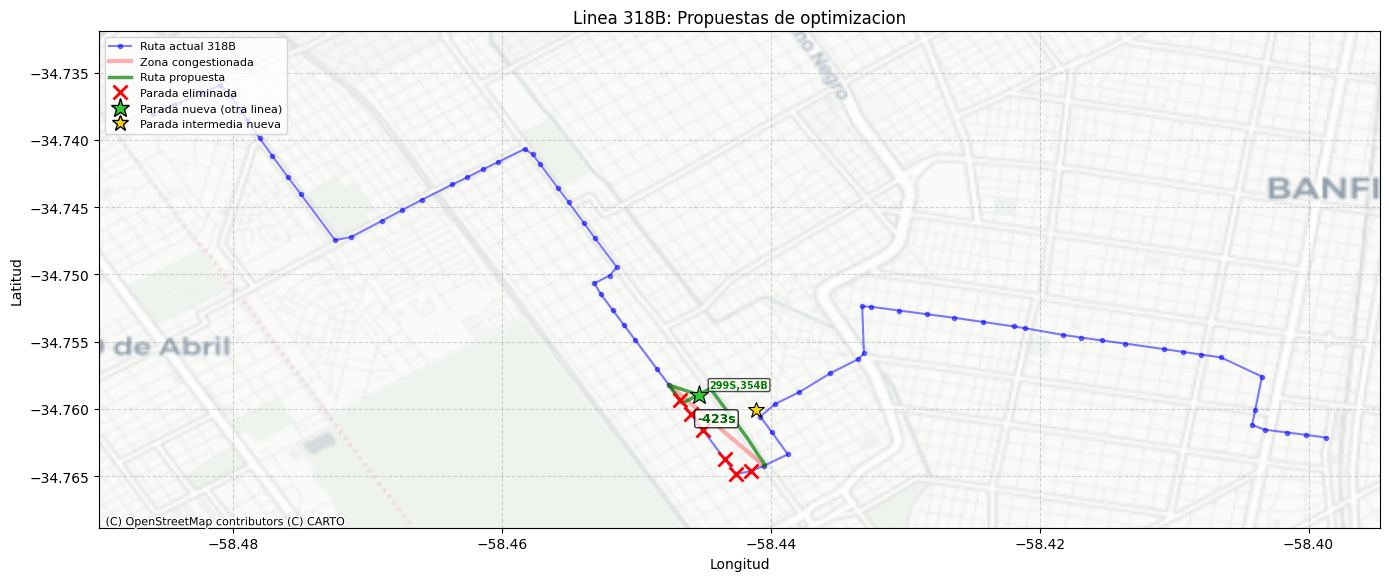

In [87]:
fig, ax = plt.subplots(figsize=(14, 10))
add_grid(ax)

ax.plot(stops_seq['lon'], stops_seq['lat'], 'b-o', markersize=3,
        linewidth=1.5, alpha=0.5, zorder=2, label=f'Ruta actual {worst_route}')

for p in proposals:
    ax.plot([p['lon_A'], p['lon_B']], [p['lat_A'], p['lat_B']],
            color='red', linewidth=3, alpha=0.3, zorder=3)
    for sid in p['removed']:
        m = stops_seq[stops_seq['stop_id']==sid]
        if not m.empty:
            ax.plot(m.iloc[0]['lon'], m.iloc[0]['lat'], 'x', color='red',
                    markersize=10, markeredgewidth=2, zorder=5)

    if p.get('path_geometry') and len(p['path_geometry']) > 1:
        alt_lons = [pt[0] for pt in p['path_geometry']]
        alt_lats = [pt[1] for pt in p['path_geometry']]
    else:
        alt_lons = [p['lon_A']] + [ns['lon'] for ns in p['new_stops']] + \
                   [es['lon'] for es in p['extra']] + [p['lon_B']]
        alt_lats = [p['lat_A']] + [ns['lat'] for ns in p['new_stops']] + \
                   [es['lat'] for es in p['extra']] + [p['lat_B']]
    ax.plot(alt_lons, alt_lats, 'g-', linewidth=2.5, alpha=0.7, zorder=4)

    for idx_p, ns in enumerate(p['new_stops']):
        if ns['is_new']:
            ax.plot(ns['lon'], ns['lat'], '*', color='limegreen', markersize=14,
                    markeredgecolor='black', markeredgewidth=0.8, zorder=6)
            lines = ','.join(ns['lines'][:2])
            offset_y = 5 + (idx_p % 3) * 12
            ax.annotate(lines, (ns['lon'], ns['lat']),
                        fontsize=7, fontweight='bold', color='green',
                        xytext=(8, offset_y), textcoords='offset points', zorder=7,
                        bbox=dict(boxstyle='round,pad=0.15', facecolor='white', alpha=0.7))
    for es in p['extra']:
        ax.plot(es['lon'], es['lat'], '*', color='gold', markersize=12,
                markeredgecolor='black', markeredgewidth=0.8, zorder=6)

    mid_lon = (p['lon_A'] + p['lon_B']) / 2
    mid_lat = (p['lat_A'] + p['lat_B']) / 2
    ax.annotate(f"-{p['savings']:.0f}s", (mid_lon, mid_lat),
                fontsize=9, fontweight='bold', color='darkgreen',
                ha='center', va='bottom', zorder=8,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

from matplotlib.lines import Line2D
legend_items = [
    Line2D([0], [0], color='blue', marker='o', markersize=3, linewidth=1.5, alpha=0.5, label=f'Ruta actual {worst_route}'),
    Line2D([0], [0], color='red', linewidth=3, alpha=0.3, label='Zona congestionada'),
    Line2D([0], [0], color='green', linewidth=2.5, alpha=0.7, label='Ruta propuesta'),
    Line2D([0], [0], marker='x', color='red', markersize=10, linestyle='None', markeredgewidth=2, label='Parada eliminada'),
    Line2D([0], [0], marker='*', color='limegreen', markersize=14, linestyle='None', markeredgecolor='black', label='Parada nueva (otra linea)'),
    Line2D([0], [0], marker='*', color='gold', markersize=12, linestyle='None', markeredgecolor='black', label='Parada intermedia nueva'),
]
ax.legend(handles=legend_items, loc='upper left', fontsize=8)

margin = 0.004
ax.set_xlim(stops_seq['lon'].min() - margin, stops_seq['lon'].max() + margin)
ax.set_ylim(stops_seq['lat'].min() - margin, stops_seq['lat'].max() + margin)
ax.set_aspect('equal')

try:
    import contextily as cx
    cx.add_basemap(ax, crs='EPSG:4326', source=cx.providers.CartoDB.Positron)
except Exception:
    pass

ax.set_xlabel('Longitud')
ax.set_ylabel('Latitud')
ax.set_title(f'Linea {worst_route}: Propuestas de optimizacion')
plt.tight_layout()
plt.show()

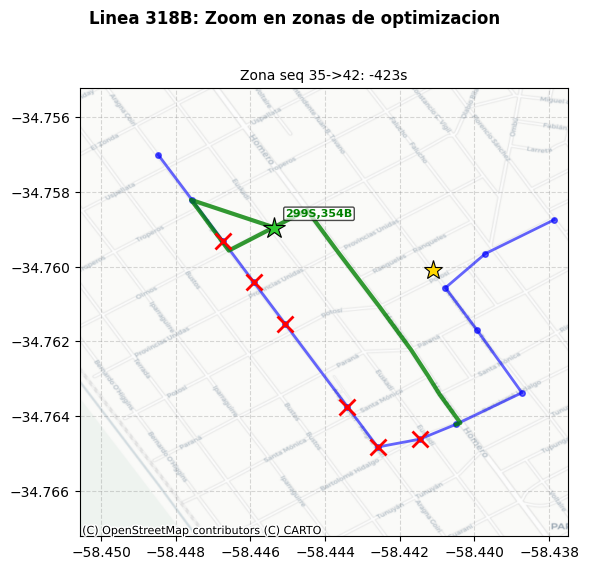

In [88]:
if proposals:
    n_zoom = min(len(proposals), 4)
    fig_zoom, axes_zoom = plt.subplots(1, n_zoom, figsize=(6 * n_zoom, 6))
    if n_zoom == 1:
        axes_zoom = [axes_zoom]

    for ax_z, p in zip(axes_zoom, proposals[:n_zoom]):
        add_grid(ax_z)
        all_lats = [p['lat_A'], p['lat_B']] + [ns['lat'] for ns in p['new_stops']] + [es['lat'] for es in p['extra']]
        all_lons = [p['lon_A'], p['lon_B']] + [ns['lon'] for ns in p['new_stops']] + [es['lon'] for es in p['extra']]
        margin_z = 0.003

        nearby_route = stops_seq[
            (stops_seq['lat'].between(min(all_lats) - margin_z, max(all_lats) + margin_z))
            & (stops_seq['lon'].between(min(all_lons) - margin_z, max(all_lons) + margin_z))
        ]
        ax_z.plot(nearby_route['lon'], nearby_route['lat'], 'b-o', markersize=4,
                  linewidth=2, alpha=0.6, zorder=2)

        for rs_id in p['removed']:
            m = stops_seq[stops_seq['stop_id'] == rs_id]
            if not m.empty:
                ax_z.plot(m.iloc[0]['lon'], m.iloc[0]['lat'], 'x', color='red', markersize=12,
                          markeredgewidth=2, zorder=5)

        if p.get('path_geometry') and len(p['path_geometry']) > 1:
            alt_lons = [pt[0] for pt in p['path_geometry']]
            alt_lats = [pt[1] for pt in p['path_geometry']]
        else:
            alt_lons = [p['lon_A']] + [ns['lon'] for ns in p['new_stops']] + [es['lon'] for es in p['extra']] + [p['lon_B']]
            alt_lats = [p['lat_A']] + [ns['lat'] for ns in p['new_stops']] + [es['lat'] for es in p['extra']] + [p['lat_B']]
        ax_z.plot(alt_lons, alt_lats, 'g-', linewidth=3, alpha=0.8, zorder=4)

        for idx_p, ns in enumerate(p['new_stops']):
            if ns['is_new']:
                ax_z.plot(ns['lon'], ns['lat'], '*', color='limegreen', markersize=16,
                          markeredgecolor='black', markeredgewidth=0.8, zorder=6)
                lines = ','.join(ns['lines'][:2])
                offset_y = 8 + (idx_p % 3) * 14
                ax_z.annotate(lines, (ns['lon'], ns['lat']),
                              fontsize=8, fontweight='bold', color='green',
                              xytext=(8, offset_y), textcoords='offset points', zorder=7,
                              bbox=dict(boxstyle='round,pad=0.15', facecolor='white', alpha=0.7))

        for es in p['extra']:
            ax_z.plot(es['lon'], es['lat'], '*', color='gold', markersize=14,
                      markeredgecolor='black', markeredgewidth=0.8, zorder=6)

        ax_z.set_xlim(min(all_lons) - margin_z, max(all_lons) + margin_z)
        ax_z.set_ylim(min(all_lats) - margin_z, max(all_lats) + margin_z)
        ax_z.set_aspect('equal')
        ax_z.set_title(f"Zona {p['zone']}: -{p['savings']:.0f}s", fontsize=10)

        try:
            import contextily as cx
            cx.add_basemap(ax_z, crs='EPSG:4326', source=cx.providers.CartoDB.Positron)
        except Exception:
            pass

    plt.suptitle(f'Linea {worst_route}: Zoom en zonas de optimizacion', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('Sin propuestas.')

In [89]:
if proposals:
    rows = []
    for p in proposals:
        n_removed = len(p['removed'])
        n_new = len([ns for ns in p['new_stops'] if ns['is_new']])
        n_extra = len(p['extra'])
        new_lines = set()
        for ns in p['new_stops']:
            new_lines.update(ns['lines'][:2])
        for es in p['extra']:
            new_lines.update(es['lines'][:2])
        rows.append({
            'Zona': p['zone'],
            'TT original': f"{p['original_tt']:.0f}s",
            'Distancia': f"{p['original_dist']:.0f}m",
            'Paradas eliminadas': n_removed,
            'Paradas nuevas': n_new + n_extra,
            'Lineas alternativas': ', '.join(sorted(new_lines)[:5]),
            'TT alternativa': f"{p['alt_tt']:.0f}s",
            'Ahorro': f"{p['savings']:.0f}s ({p['savings']/60:.1f}min)",
        })
    summary_df = pd.DataFrame(rows)
    print('=== Resumen de propuestas ===')
    print(summary_df.to_string(index=False))
    print(f"\nAhorro total: {total_savings:.0f}s ({total_savings/60:.1f} min) — {total_savings/total_tt*100:.1f}%")
else:
    print('Sin propuestas.')

=== Resumen de propuestas ===
      Zona TT original Distancia  Paradas eliminadas  Paradas nuevas Lineas alternativas TT alternativa        Ahorro
seq 35->42        526s     1008m                   6               2    174B, 299S, 354B           103s 423s (7.1min)

Ahorro total: 423s (7.1 min) — 15.5%


## Persistencia del modelo

Los modelos se guardan como archivos `.joblib`, permitiendo cargarlos y usarlos sin reentrenar.

In [90]:
model_tt_path = OUTPUTS / "model_travel_time.joblib"
model_hw_path = OUTPUTS / "model_headway.joblib"

if model_tt_path.exists():
    bundle_tt = joblib.load(model_tt_path)
    print(f"Travel time model: {bundle_tt['model_name']}")
    print(f"   Features: {bundle_tt['features']}")
else:
    print("⚠ model_travel_time.joblib no encontrado")

if model_hw_path.exists():
    bundle_hw = joblib.load(model_hw_path)
    print(f"Headway model: {bundle_hw['model_name']}")
    print(f"   Features: {bundle_hw['features']}")
else:
    print("⚠ model_headway.joblib no encontrado")

print("\nDemo de predicción sin reentrenamiento:")
if model_tt_path.exists():
    X_test = pd.DataFrame([{
        "distance_m": 800,
        "zone_lat": -34.60,
        "zone_lon": -58.39,
        "hour_bin": 1,
        "day_type": 0,
        "route_enc": 5000,
        "n_semaphores": 3,
        "pct_semaphores_operational": 0.8,
    }])
    X_test = X_test[[c for c in bundle_tt["features"] if c in X_test.columns]]
    print(f"  Segmento demo (800m, hora pico): {bundle_tt['model'].predict(X_test)[0]:.0f}s")

Travel time model: RandomForest
   Features: ['distance_m', 'zone_lat', 'zone_lon', 'hour_bin', 'day_type', 'n_semaphores', 'pct_semaphores_operational']
Headway model: GradientBoosting
   Features: ['stop_lat', 'stop_lon', 'hour_bin_enc', 'day_type_enc', 'n_vehicles_active', 'headway_programado', 'route_enc']

Demo de predicción sin reentrenamiento:
  Segmento demo (800m, hora pico): 157s


/home/kerty/Projects/transportia/.venv/lib/python3.14/site-packages/sklearn/utils/validation.py:2684: UserWarning: X has feature names, but RandomForestRegressor was fitted without feature names
  warnings.warn(


## Evaluación en rutas no vistas (Holdout)

Para validar que el modelo generaliza a rutas que no vio durante el entrenamiento, seleccionamos **20 rutas al azar** del pool de ~566 rutas CABA que NO fueron parte de las 200 usadas en training.

Esto nos permite medir si hay overfitting por ruta: si el modelo memorizó patrones específicos de las 200 rutas de train, sus predicciones en rutas nuevas deberían ser significativamente peores.

**Metodología:**
- Las 20 rutas holdout pasan por CABA y tienen >= 50 observaciones en AMBA
- Se les aplica el mismo feature engineering que a las rutas de train
- Se evalúa el modelo ya entrenado (sin re-entrenar) sobre sus segmentos
- Se compara MAE/RMSE/R² contra el test set de train

In [91]:
holdout_metrics_path = OUTPUTS / "metrics_holdout.json"
holdout_segs_path = OUTPUTS / "holdout_segments.parquet"
holdout_diag_path = OUTPUTS / "holdout_diagnostics.png"

if holdout_metrics_path.exists():
    with open(holdout_metrics_path) as f:
        hm = json.load(f)

    print("=== Holdout Evaluation ===")
    print(f"Rutas holdout: {len(hm['holdout_routes'])}")
    print(f"Segmentos evaluados: {hm['n_holdout_segments']:,}")
    print(f"Peor ruta holdout: {hm['worst_route']}")
    print()

    ho = hm['holdout_metrics']
    tr = hm.get('train_metrics')

    print(f"{'Set':<25} {'MAE':>10} {'RMSE':>10} {'R²':>10}")
    print("-" * 57)
    if tr:
        print(f"{'Train test (200 rutas)':<25} {tr['MAE']:>10.1f} {tr['RMSE']:>10.1f} {tr['R2']:>10.3f}")
    print(f"{'Holdout (20 rutas)':<25} {ho['MAE']:>10.1f} {ho['RMSE']:>10.1f} {ho['R2']:>10.3f}")
    if tr:
        diff_mae = ho['MAE'] - tr['MAE']
        diff_rmse = ho['RMSE'] - tr['RMSE']
        diff_r2 = ho['R2'] - tr['R2']
        print(f"\nDegradación: MAE {diff_mae:+.1f}s, RMSE {diff_rmse:+.1f}s, R² {diff_r2:+.3f}")
        if abs(diff_r2) < 0.1:
            print("El modelo generaliza bien a rutas no vistas.")
        else:
            print("El modelo degrada significativamente en rutas nuevas.")
else:
    print("Run scripts/08_holdout_eval.py first.")

=== Holdout Evaluation ===
Rutas holdout: 20
Segmentos evaluados: 21,098
Peor ruta holdout: 97B

Set                              MAE       RMSE         R²
---------------------------------------------------------
Train test (200 rutas)          34.6       49.3      0.434
Holdout (20 rutas)              37.8       54.6      0.229

Degradación: MAE +3.2s, RMSE +5.3s, R² -0.206
El modelo degrada significativamente en rutas nuevas.


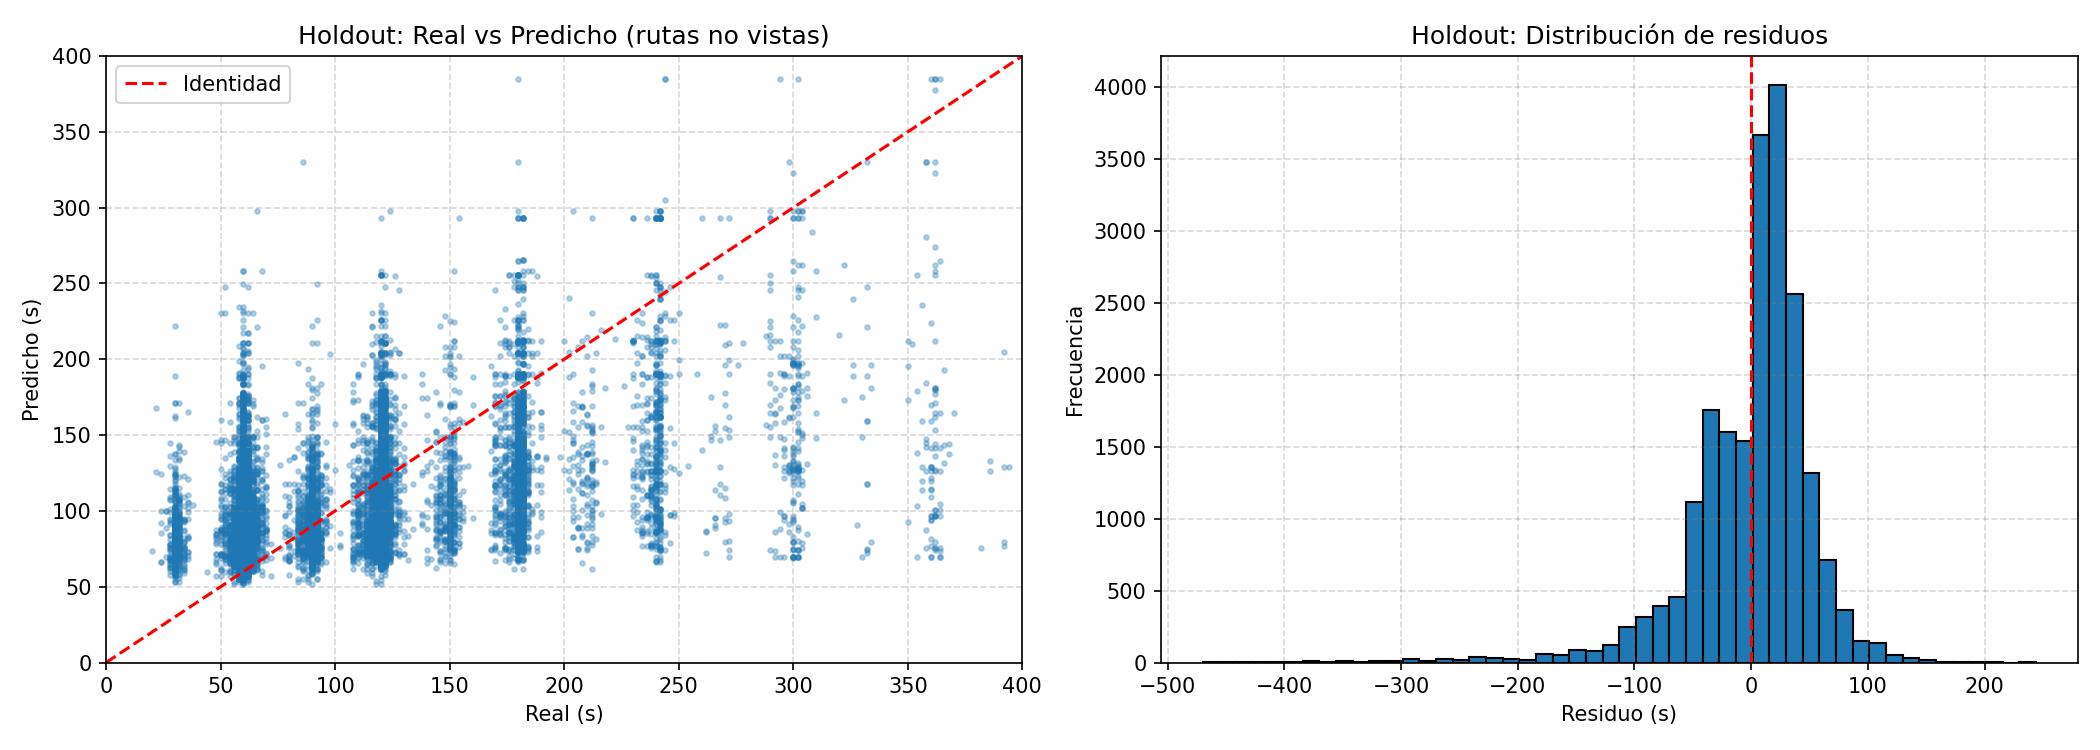

In [92]:
if holdout_diag_path.exists():
    from IPython.display import Image, display
    display(Image(filename=str(holdout_diag_path)))
else:
    print("Run scripts/08_holdout_eval.py first.")

### Simulador sobre la peor ruta del holdout

Ejecutamos el simulador de rutas sobre la **peor ruta del holdout** — una ruta que el modelo nunca vio durante el entrenamiento. Esto demuestra que el pipeline funciona en rutas completamente nuevas.

In [93]:
if holdout_metrics_path.exists() and not holdout_segs_path.exists() is False:
    with open(holdout_metrics_path) as f:
        hm = json.load(f)
    worst_holdout = hm['worst_route']
    holdout_routes = hm['holdout_routes']

    hsf = load_parquet('holdout_segments.parquet')
    if hsf.empty:
        print('No holdout segments data.')
    else:
        r_data = hsf[(hsf['route_short_name'] == worst_holdout) & hsf['stop_A_lat'].notna()]
        if r_data.empty:
            r_data = hsf[hsf['stop_A_lat'].notna()]
            worst_holdout = r_data['route_short_name'].value_counts().index[0]
            r_data = r_data[r_data['route_short_name'] == worst_holdout]

        best_trip = r_data.groupby('trip_id').size().sort_values(ascending=False).index[0]
        trip_data = r_data[r_data['trip_id'] == best_trip]

        stops_seq_ho = trip_data.groupby('arrival_seq').agg(
            stop_id=('stop_id_A', 'first'), lat=('stop_A_lat', 'median'), lon=('stop_A_lon', 'median'),
        ).sort_index().reset_index(drop=True)

        seg_stats_ho = trip_data[trip_data['next_seq'] == trip_data['arrival_seq'] + 1].groupby(
            'arrival_seq'
        ).agg(
            med_tt=('travel_time_observed', 'median'),
            med_dist=('distance_m', 'median'),
        ).sort_index().reset_index(drop=True)

        total_tt_ho = seg_stats_ho['med_tt'].sum()
        print(f'Holdout worst route: {worst_holdout}')
        print(f'  {len(stops_seq_ho)} paradas, {seg_stats_ho["med_dist"].sum():.0f}m totales')
        print(f'  Tiempo total observado: {total_tt_ho:.0f}s ({total_tt_ho/60:.1f} min)')

        # Build graph using ALL segments (train + holdout) for connectivity
        sf_all = load_parquet('segments_features.parquet')
        sf_combined = pd.concat([sf_all[['stop_id_A','stop_id_B','stop_A_lat','stop_A_lon','stop_B_lat','stop_B_lon','travel_time_observed','route_short_name']],
                                 hsf[['stop_id_A','stop_id_B','stop_A_lat','stop_A_lon','stop_B_lat','stop_B_lon','travel_time_observed','route_short_name']]])

        all_a = sf_combined[['stop_id_A','stop_A_lat','stop_A_lon']].dropna().drop_duplicates('stop_id_A')
        all_a.columns = ['stop_id','lat','lon']
        all_b = sf_combined[['stop_id_B','stop_B_lat','stop_B_lon']].dropna().drop_duplicates('stop_id_B')
        all_b.columns = ['stop_id','lat','lon']
        all_stops = pd.concat([all_a, all_b]).drop_duplicates('stop_id')

        bbox_lat = (stops_seq_ho['lat'].min()-0.015, stops_seq_ho['lat'].max()+0.015)
        bbox_lon = (stops_seq_ho['lon'].min()-0.015, stops_seq_ho['lon'].max()+0.015)
        nearby_ho = all_stops[all_stops['lat'].between(*bbox_lat) & all_stops['lon'].between(*bbox_lon)]
        stop_routes_ho = sf_combined.dropna(subset=['stop_A_lat']).groupby('stop_id_A')[
            'route_short_name'].apply(lambda x: list(x.unique())[:5]).to_dict()

        graph_edges = sf_combined.dropna(subset=['stop_A_lat']).groupby(['stop_id_A','stop_id_B']).agg(
            med_tt=('travel_time_observed','median'), n=('travel_time_observed','count'),
        ).reset_index()
        graph_edges = graph_edges[graph_edges['n'] >= 3]
        zone_ids = set(nearby_ho['stop_id'])
        ze = graph_edges[graph_edges['stop_id_A'].isin(zone_ids) & graph_edges['stop_id_B'].isin(zone_ids)]

        bus_graph_ho = nx.DiGraph()
        for _, r in ze.iterrows():
            bus_graph_ho.add_edge(r['stop_id_A'], r['stop_id_B'], weight=r['med_tt'])

        route_stop_ids_ho = set(stops_seq_ho['stop_id'])
        coords = np.radians(nearby_ho[['lat','lon']].values)
        tree = cKDTree(coords)
        radius_rad = (MAX_GAP_M * 2) / 6_371_000
        pairs = tree.query_pairs(radius_rad)
        for i, j in pairs:
            s, t = nearby_ho.iloc[i], nearby_ho.iloc[j]
            if s['stop_id'] in route_stop_ids_ho and t['stop_id'] in route_stop_ids_ho:
                continue
            if not bus_graph_ho.has_edge(s['stop_id'], t['stop_id']):
                d = haversine_m(s['lat'], s['lon'], t['lat'], t['lon'])
                if use_osrm:
                    rt = get_route(s['lon'], s['lat'], t['lon'], t['lat'])
                    if rt:
                        bus_graph_ho.add_edge(s['stop_id'], t['stop_id'], weight=rt['duration_s'], geometry=rt['geometry'])
                        bus_graph_ho.add_edge(t['stop_id'], s['stop_id'], weight=rt['duration_s'], geometry=rt['geometry'])
                        continue
                bus_graph_ho.add_edge(s['stop_id'], t['stop_id'], weight=d/MEDIAN_SPEED)
                bus_graph_ho.add_edge(t['stop_id'], s['stop_id'], weight=d/MEDIAN_SPEED)

        print(f'  Grafo: {bus_graph_ho.number_of_nodes()} nodos, {bus_graph_ho.number_of_edges()} aristas')

        # Find bottlenecks and propose alternatives
        p90_ho = seg_stats_ho['med_tt'].quantile(0.85)
        mean_speed_ho = seg_stats_ho['med_dist'].sum() / seg_stats_ho['med_tt'].sum()

        zones_ho = []
        i = 0
        while i < len(seg_stats_ho):
            if seg_stats_ho.iloc[i]['med_tt'] > p90_ho:
                start = i
                while i < len(seg_stats_ho) and seg_stats_ho.iloc[i]['med_tt'] > p90_ho * 0.6:
                    i += 1
                end = min(i, len(seg_stats_ho))
                if end - start >= 1:
                    zt = seg_stats_ho.iloc[start:end]['med_tt'].sum()
                    zd = seg_stats_ho.iloc[start:end]['med_dist'].sum()
                    expected = zd / mean_speed_ho
                    if zt > expected * 1.3 and zt > 120:
                        zones_ho.append({'start': start, 'end': end, 'tt': zt, 'dist': zd})
            else:
                i += 1

        all_stops_map_ho = nearby_ho.set_index('stop_id')[['lat','lon']].to_dict('index')
        proposals_ho = []
        for z in zones_ho:
            a = stops_seq_ho.iloc[z['start']]
            b = stops_seq_ho.iloc[z['end']]
            try:
                path = nx.shortest_path(bus_graph_ho, a['stop_id'], b['stop_id'], weight='weight')
                path_tt = sum(bus_graph_ho[path[i]][path[i+1]]['weight'] for i in range(len(path)-1))
            except (nx.NetworkXNoPath, KeyError):
                path = [a['stop_id'], b['stop_id']]
                path_tt = z['tt']

            removed = [stops_seq_ho.iloc[idx]['stop_id'] for idx in range(z['start']+1, z['end'])]
            new_stops = []
            for sid in path[1:-1]:
                info = all_stops_map_ho.get(sid)
                if info:
                    new_stops.append({'stop_id': sid, 'lat': info['lat'], 'lon': info['lon'],
                                      'lines': stop_routes_ho.get(sid, [])[:5],
                                      'is_new': sid not in route_stop_ids_ho})

            all_pts = [(a['lat'], a['lon'])] + [(ns['lat'], ns['lon']) for ns in new_stops] + [(b['lat'], b['lon'])]
            extra = []
            for idx in range(len(all_pts)-1):
                gap = haversine_m(all_pts[idx][0], all_pts[idx][1], all_pts[idx+1][0], all_pts[idx+1][1])
                if gap > MAX_GAP_M:
                    mid = ((all_pts[idx][0]+all_pts[idx+1][0])/2, (all_pts[idx][1]+all_pts[idx+1][1])/2)
                    close = nearby_ho[(abs(nearby_ho['lat']-mid[0])<0.003) & (abs(nearby_ho['lon']-mid[1])<0.003)
                                      & (~nearby_ho['stop_id'].isin(route_stop_ids_ho))]
                    if not close.empty:
                        c = close.iloc[0]
                        extra.append({'stop_id': c['stop_id'], 'lat': c['lat'], 'lon': c['lon'],
                                      'lines': stop_routes_ho.get(c['stop_id'], [])[:5], 'gap': gap})

            max_gap = max(haversine_m(all_pts[i][0], all_pts[i][1], all_pts[i+1][0], all_pts[i+1][1])
                          for i in range(len(all_pts)-1))

            path_geometry = []
            for k in range(len(path) - 1):
                edge_data = bus_graph_ho[path[k]][path[k+1]]
                geom = edge_data.get('geometry')
                if geom:
                    path_geometry.extend(geom)
                else:
                    s_info = all_stops_map_ho.get(path[k])
                    t_info = all_stops_map_ho.get(path[k+1])
                    if s_info and t_info:
                        path_geometry.append([s_info['lon'], s_info['lat']])
                        path_geometry.append([t_info['lon'], t_info['lat']])

            proposals_ho.append({
                'zone': f"seq {z['start']}->{z['end']}", 'stop_A': a['stop_id'], 'stop_B': b['stop_id'],
                'lat_A': a['lat'], 'lon_A': a['lon'], 'lat_B': b['lat'], 'lon_B': b['lon'],
                'original_tt': z['tt'], 'original_dist': z['dist'],
                'removed': removed, 'new_stops': new_stops, 'extra': extra,
                'alt_tt': path_tt, 'savings': max(0, z['tt'] - path_tt), 'max_gap': max_gap,
                'path_geometry': path_geometry,
            })

            print(f"Zona {proposals_ho[-1]['zone']}: {a['stop_id']} -> {b['stop_id']}")
            print(f"  Problema: {z['tt']:.0f}s en {z['dist']:.0f}m")
            print(f"  Tiempo: {z['tt']:.0f}s -> {path_tt:.0f}s (ahorro {proposals_ho[-1]['savings']:.0f}s)")

        total_savings_ho = sum(p['savings'] for p in proposals_ho)
        print(f"\nAHORRO TOTAL: {total_savings_ho:.0f}s ({total_savings_ho/60:.1f} min) — {total_savings_ho/total_tt_ho*100:.1f}%")
else:
    print('Run scripts/08_holdout_eval.py first.')

Holdout worst route: 97B
  51 paradas, 13637m totales
  Tiempo total observado: 3428s (57.1 min)
  Grafo: 7353 nodos, 945600 aristas
Zona seq 0->1: 6490101154 -> 6490120567
  Problema: 240s en 349m
  Tiempo: 240s -> 45s (ahorro 195s)
Zona seq 15->18: 6434120558 -> 6434113612
  Problema: 468s en 1154m
  Tiempo: 468s -> 97s (ahorro 371s)
Zona seq 28->29: 20317 -> 206207
  Problema: 138s en 171m
  Tiempo: 138s -> 40s (ahorro 98s)
Zona seq 30->31: 2031380 -> 20418
  Problema: 256s en 471m
  Tiempo: 256s -> 21s (ahorro 235s)

AHORRO TOTAL: 900s (15.0 min) — 26.2%


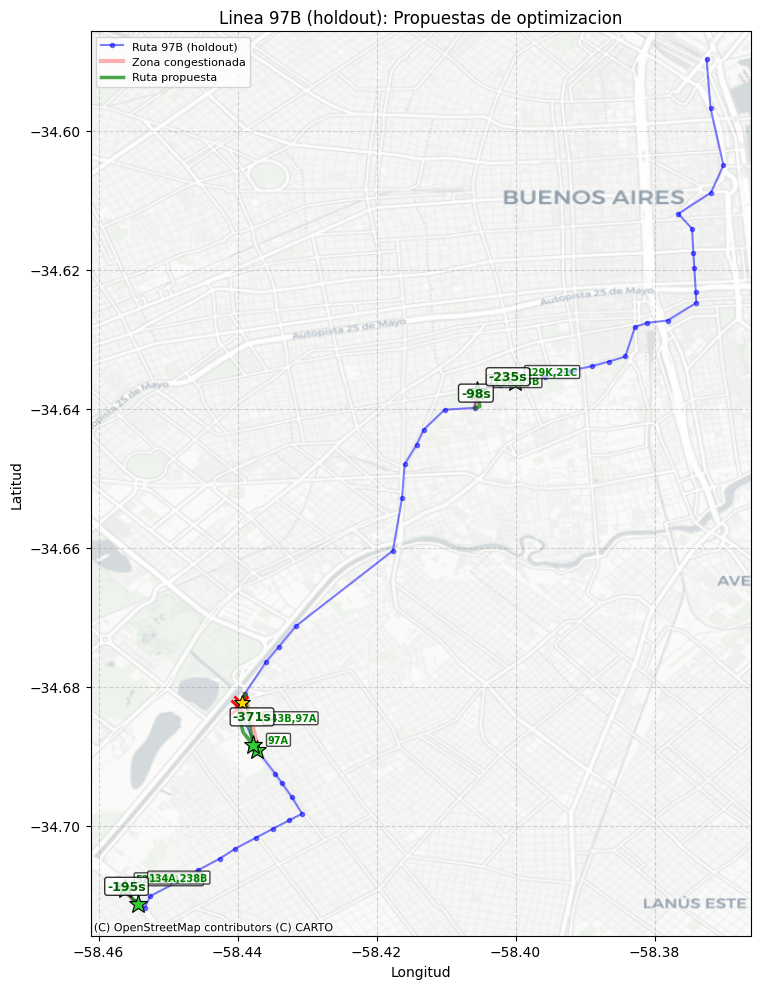

In [94]:
if proposals_ho:
    fig, ax = plt.subplots(figsize=(14, 10))
    add_grid(ax)

    ax.plot(stops_seq_ho['lon'], stops_seq_ho['lat'], 'b-o', markersize=3,
            linewidth=1.5, alpha=0.5, zorder=2, label=f'Ruta actual {worst_holdout}')

    for p in proposals_ho:
        ax.plot([p['lon_A'], p['lon_B']], [p['lat_A'], p['lat_B']],
                color='red', linewidth=3, alpha=0.3, zorder=3)
        for sid in p['removed']:
            m = stops_seq_ho[stops_seq_ho['stop_id']==sid]
            if not m.empty:
                ax.plot(m.iloc[0]['lon'], m.iloc[0]['lat'], 'x', color='red',
                        markersize=10, markeredgewidth=2, zorder=5)

        if p.get('path_geometry') and len(p['path_geometry']) > 1:
            alt_lons = [pt[0] for pt in p['path_geometry']]
            alt_lats = [pt[1] for pt in p['path_geometry']]
        else:
            alt_lons = [p['lon_A']] + [ns['lon'] for ns in p['new_stops']] + [es['lon'] for es in p['extra']] + [p['lon_B']]
            alt_lats = [p['lat_A']] + [ns['lat'] for ns in p['new_stops']] + [es['lat'] for es in p['extra']] + [p['lat_B']]
        ax.plot(alt_lons, alt_lats, 'g-', linewidth=2.5, alpha=0.7, zorder=4)

        for idx_p, ns in enumerate(p['new_stops']):
            if ns['is_new']:
                ax.plot(ns['lon'], ns['lat'], '*', color='limegreen', markersize=14,
                        markeredgecolor='black', markeredgewidth=0.8, zorder=6)
                lines = ','.join(ns['lines'][:2])
                offset_y = 5 + (idx_p % 3) * 12
                ax.annotate(lines, (ns['lon'], ns['lat']),
                            fontsize=7, fontweight='bold', color='green',
                            xytext=(8, offset_y), textcoords='offset points', zorder=7,
                            bbox=dict(boxstyle='round,pad=0.15', facecolor='white', alpha=0.7))
        for es in p['extra']:
            ax.plot(es['lon'], es['lat'], '*', color='gold', markersize=12,
                    markeredgecolor='black', markeredgewidth=0.8, zorder=6)

        mid_lon = (p['lon_A'] + p['lon_B']) / 2
        mid_lat = (p['lat_A'] + p['lat_B']) / 2
        ax.annotate(f"-{p['savings']:.0f}s", (mid_lon, mid_lat),
                    fontsize=9, fontweight='bold', color='darkgreen',
                    ha='center', va='bottom', zorder=8,
                    bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))

    from matplotlib.lines import Line2D
    legend_items = [
        Line2D([0], [0], color='blue', marker='o', markersize=3, linewidth=1.5, alpha=0.5, label=f'Ruta {worst_holdout} (holdout)'),
        Line2D([0], [0], color='red', linewidth=3, alpha=0.3, label='Zona congestionada'),
        Line2D([0], [0], color='green', linewidth=2.5, alpha=0.7, label='Ruta propuesta'),
    ]
    ax.legend(handles=legend_items, loc='upper left', fontsize=8)

    margin = 0.004
    ax.set_xlim(stops_seq_ho['lon'].min() - margin, stops_seq_ho['lon'].max() + margin)
    ax.set_ylim(stops_seq_ho['lat'].min() - margin, stops_seq_ho['lat'].max() + margin)
    ax.set_aspect('equal')

    try:
        import contextily as cx
        cx.add_basemap(ax, crs='EPSG:4326', source=cx.providers.CartoDB.Positron)
    except Exception:
        pass

    ax.set_xlabel('Longitud')
    ax.set_ylabel('Latitud')
    ax.set_title(f'Linea {worst_holdout} (holdout): Propuestas de optimizacion')
    plt.tight_layout()
    plt.show()
else:
    print('Sin propuestas para la ruta holdout.')

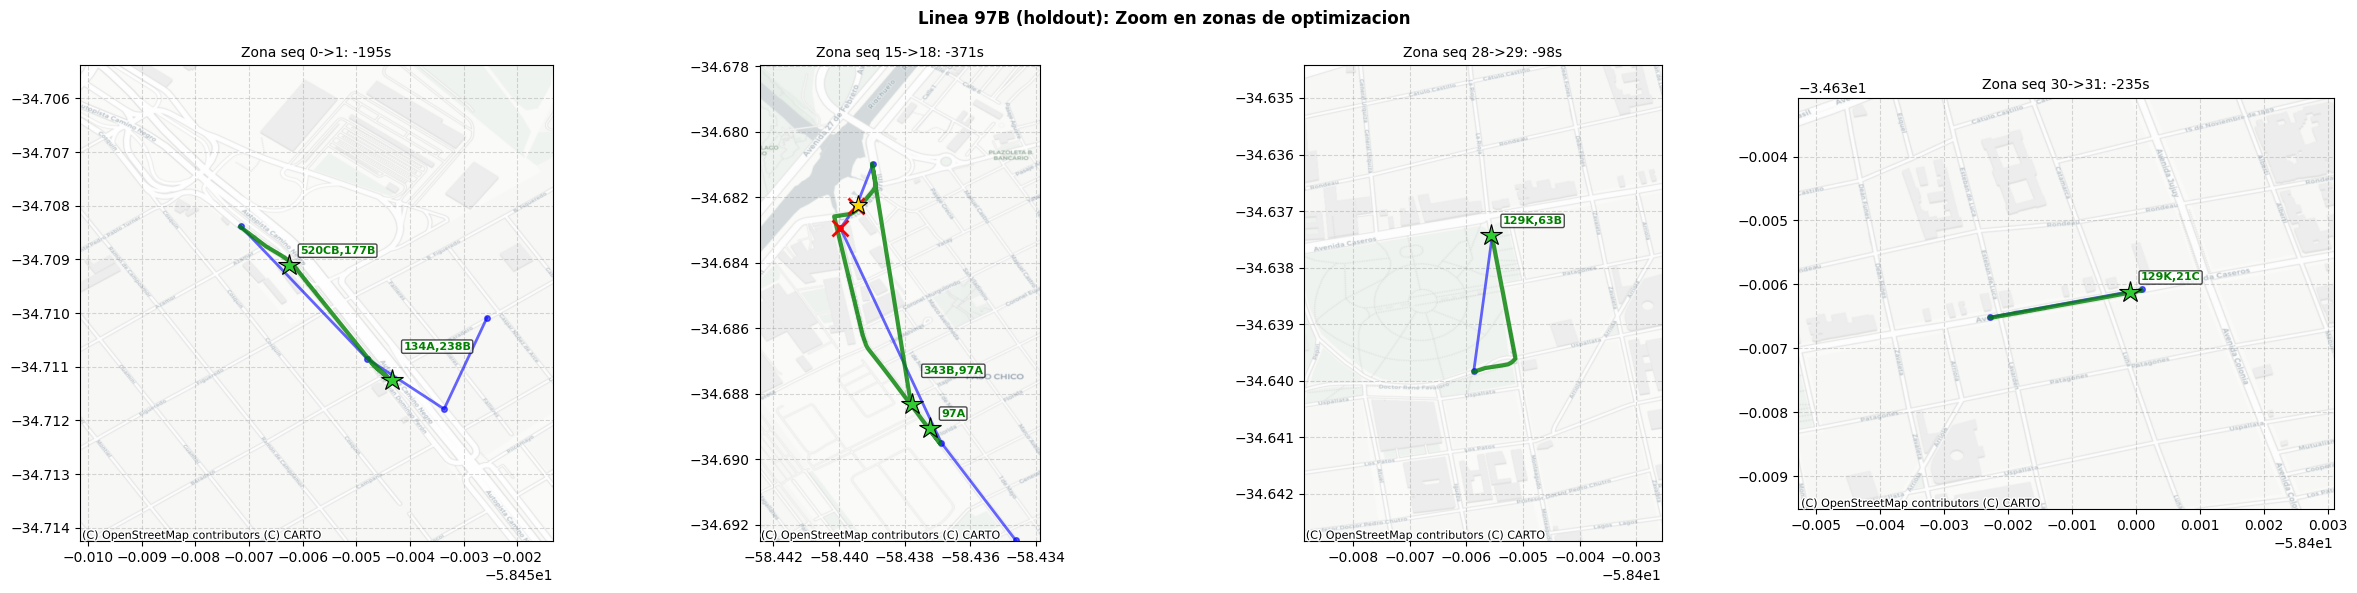

In [95]:
if proposals_ho:
    n_zoom = min(len(proposals_ho), 4)
    fig_zoom, axes_zoom = plt.subplots(1, n_zoom, figsize=(6 * n_zoom, 6))
    if n_zoom == 1:
        axes_zoom = [axes_zoom]

    for ax_z, p in zip(axes_zoom, proposals_ho[:n_zoom]):
        add_grid(ax_z)
        all_lats = [p['lat_A'], p['lat_B']] + [ns['lat'] for ns in p['new_stops']] + [es['lat'] for es in p['extra']]
        all_lons = [p['lon_A'], p['lon_B']] + [ns['lon'] for ns in p['new_stops']] + [es['lon'] for es in p['extra']]
        margin_z = 0.003

        nearby_route = stops_seq_ho[
            (stops_seq_ho['lat'].between(min(all_lats) - margin_z, max(all_lats) + margin_z))
            & (stops_seq_ho['lon'].between(min(all_lons) - margin_z, max(all_lons) + margin_z))
        ]
        ax_z.plot(nearby_route['lon'], nearby_route['lat'], 'b-o', markersize=4,
                  linewidth=2, alpha=0.6, zorder=2)

        for rs_id in p['removed']:
            m = stops_seq_ho[stops_seq_ho['stop_id'] == rs_id]
            if not m.empty:
                ax_z.plot(m.iloc[0]['lon'], m.iloc[0]['lat'], 'x', color='red', markersize=12,
                          markeredgewidth=2, zorder=5)

        if p.get('path_geometry') and len(p['path_geometry']) > 1:
            alt_lons = [pt[0] for pt in p['path_geometry']]
            alt_lats = [pt[1] for pt in p['path_geometry']]
        else:
            alt_lons = [p['lon_A']] + [ns['lon'] for ns in p['new_stops']] + [es['lon'] for es in p['extra']] + [p['lon_B']]
            alt_lats = [p['lat_A']] + [ns['lat'] for ns in p['new_stops']] + [es['lat'] for es in p['extra']] + [p['lat_B']]
        ax_z.plot(alt_lons, alt_lats, 'g-', linewidth=3, alpha=0.8, zorder=4)

        for idx_p, ns in enumerate(p['new_stops']):
            if ns['is_new']:
                ax_z.plot(ns['lon'], ns['lat'], '*', color='limegreen', markersize=16,
                          markeredgecolor='black', markeredgewidth=0.8, zorder=6)
                lines = ','.join(ns['lines'][:2])
                offset_y = 8 + (idx_p % 3) * 14
                ax_z.annotate(lines, (ns['lon'], ns['lat']),
                              fontsize=8, fontweight='bold', color='green',
                              xytext=(8, offset_y), textcoords='offset points', zorder=7,
                              bbox=dict(boxstyle='round,pad=0.15', facecolor='white', alpha=0.7))

        for es in p['extra']:
            ax_z.plot(es['lon'], es['lat'], '*', color='gold', markersize=14,
                      markeredgecolor='black', markeredgewidth=0.8, zorder=6)

        ax_z.set_xlim(min(all_lons) - margin_z, max(all_lons) + margin_z)
        ax_z.set_ylim(min(all_lats) - margin_z, max(all_lats) + margin_z)
        ax_z.set_aspect('equal')
        ax_z.set_title(f"Zona {p['zone']}: -{p['savings']:.0f}s", fontsize=10)

        try:
            import contextily as cx
            cx.add_basemap(ax_z, crs='EPSG:4326', source=cx.providers.CartoDB.Positron)
        except Exception:
            pass

    plt.suptitle(f'Linea {worst_holdout} (holdout): Zoom en zonas de optimizacion', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print('Sin propuestas para zoom.')

## Reflexiones finales

### Limitaciones
- **Datos de 24h únicamente:** Una sola jornada no captura la variabilidad semanal ni estacional.
- **Cobertura GPS:** Solo ~64% de los pings tenían `stop_id`, lo que reduce las observaciones por segmento.
- **Generalización de segmentos:** El simulador predice para segmentos nuevos usando features físicos, pero la confianza disminuye en zonas sin datos observados.
- **Semáforos solo CABA:** Las features de semáforos no aplican para segmentos en el conurbano.
- **route_id matching:** El 70% de los pings del feed simple eran huérfanos respecto al GTFS; el feed FULL mitigó esto con `trip_id` directo.
- **Routing sin OSRM:** Si OSRM no está disponible, las distancias son haversine (línea recta) y los tiempos estimados con velocidad constante.

### Mejoras con más datos
- Recolectar datos de múltiples días/semanas para capturar variabilidad temporal.
- Incorporar datos de sube/baja de pasajeros para modelar demanda.
- Agregar features de tráfico en tiempo real (velocidad por tramo).
- Modelar time-series para capturar tendencias y estacionalidad.

### Aplicabilidad real
- El modelo de travel time permite evaluar rutas alternativas sin necesidad de prueba piloto.
- El modelo de headway identifica paradas con peor frecuencia, priorizando intervenciones.
- El análisis de eficiencia cuantifica la brecha entre plan y realidad por ruta.
- El simulador de rutas permite proponer desvíos concretos, evaluando ahorro en tiempo y cobertura de paradas.

### Conexión con Entregable 4
- Los modelos `.joblib` están listos para ser integrados en una API (FastAPI/Flask).
- El pipeline modular permite automatizar el reentrenamiento periódico.
- El simulador puede exponerse como endpoint para consultas de planificación.